In [61]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [62]:
df= pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [63]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [64]:
print(df.shape)

(10000, 14)


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [68]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [69]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [70]:
df.drop(columns=['CustomerId','RowNumber','Surname'], inplace= True)

In [81]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [82]:
x= df.drop(columns=['Exited'])
y= df['Exited']

In [83]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)

In [84]:
x_train.shape

(8000, 11)

In [85]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

In [86]:
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [87]:
x_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [97]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [150]:
model= Sequential()

model.add(Dense(11,activation= 'relu', input_dim= 11)) ## input layer  ## hidden layer
model.add(Dense(11,activation= 'relu', input_dim=11))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [151]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [165]:
model.compile(loss='binary_crossentropy', optimizer= 'Adam',metrics=['accuracy'])

In [183]:
history= model.fit(x_train_scaled, y_train, epochs= 100, validation_split= 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8683 - loss: 0.3259 - val_accuracy: 0.8494 - val_loss: 0.3386
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8661 - loss: 0.3256 - val_accuracy: 0.8550 - val_loss: 0.3370
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8675 - loss: 0.3254 - val_accuracy: 0.8544 - val_loss: 0.3376
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3253 - val_accuracy: 0.8531 - val_loss: 0.3378
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8684 - loss: 0.3257 - val_accuracy: 0.8531 - val_loss: 0.3373
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8675 - loss: 0.3254 - val_accuracy: 0.8587 - val_loss: 0.3382
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8689 - loss: 0.3247 - val_accuracy: 0.8587 - val_loss: 0.3381
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3254 - val_accu

In [ ]:
model.layers[0].get_weights()    # 11 inout * 3 input layer neuron = 33 and + 3 bias so total 36 weights 

In [184]:
model.layers[1].get_weights()

[array([[-0.5010598 ,  0.16783513,  0.07117084,  0.34080046,  0.3244133 ,
         -0.29270023,  0.15053092,  0.00968706, -1.0830754 , -0.3948856 ,
          0.27649987],
        [-0.429764  , -0.24488567,  0.09192342, -0.34485403, -0.00649687,
         -0.15168014,  0.26812667, -0.0304117 ,  0.33589816, -0.52342695,
          0.5474195 ],
        [-0.14620383, -0.7182848 ,  0.6469232 , -0.82987547,  0.65514433,
          0.7378917 ,  0.50263536, -0.11744245, -0.23998162,  0.02132353,
         -1.241582  ],
        [-0.47116414, -0.03392328,  0.03522801,  0.10651854, -0.30041274,
         -0.15031204, -0.20406128,  0.52231616, -0.38238907,  0.4921127 ,
          0.08879992],
        [ 0.12571193,  0.34254783,  0.58755857,  0.35293967, -0.38446313,
          0.9317734 , -0.6637535 ,  0.01648382, -0.31683147,  0.01048476,
         -1.0733334 ],
        [ 0.08354893, -0.50008255, -0.1966291 , -0.27060512,  0.05035348,
          0.01703594,  0.044595  , -0.38588288,  0.4230894 , -0.2413624

In [185]:
y_log= model.predict(x_test_scaled)  # output should be 0 or 1 so # decide one threshold value  ( if <0.5=0 and if >0.7 =1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [186]:
y_pred= np.where(y_log>0.5,1,0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(2000, 1))

In [188]:
from sklearn.metrics import accuracy_score

score= accuracy_score(y_test, y_pred)
score

0.8605

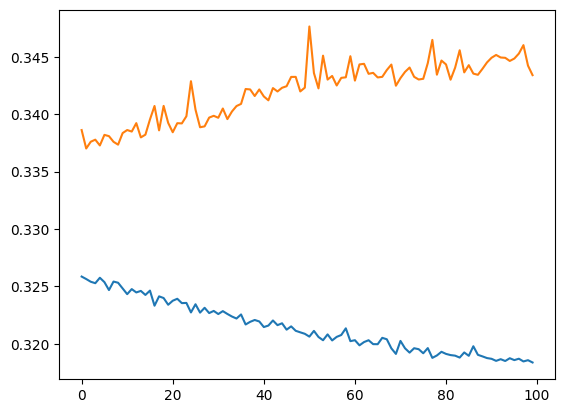

In [189]:
# check the comparision  using matplotlib

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

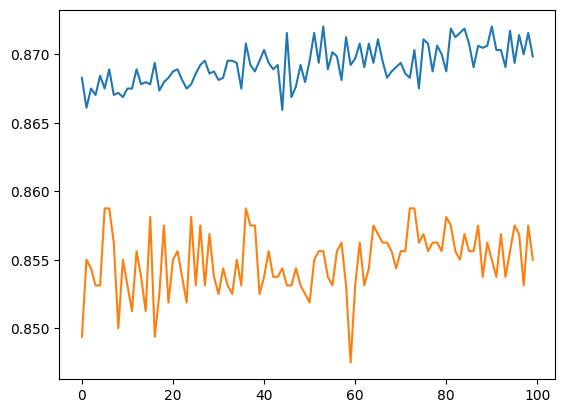

In [190]:
 plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])